# 🛡️ Cyberbullying Detection – NLP Project
### End-to-End Pipeline: Preprocessing → Feature Engineering → Model Training → Evaluation → Best Model

**Dataset:** `new_tweets.csv` — Tweet texts labeled with cyberbullying types  
**Classes:** `gender`, `religion`, `age`, `ethnicity`, `not_cyberbullying`, `other_cyberbullying`  
**Models Used:** Logistic Regression · Random Forest · Multinomial Naive Bayes · XGBoost (via sklearn API)  
**Handling Imbalance:** Class weights + SMOTE (on TF-IDF matrix)

---
## 📦 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

# Core
import numpy as np
import pandas as pd
import re
import string
import pickle
import os

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer

# Preprocessing / Splitting
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder

# Imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB

# Metrics
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, f1_score
)

# NLTK
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---
## 📊 2. Load & Explore Dataset (EDA)

In [2]:
df = pd.read_csv(r"C:\Users\Kartik\Desktop\CyberBulling Detection final\CyberBulling Detection\cyberbullying_tweets.csv")

# Drop unnamed index column if present
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

print(f"Dataset Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(5)

Dataset Shape: (47692, 2)
Columns: ['tweet_text', 'cyberbullying_type']


,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying


In [3]:
print("=" * 50)
print("Basic Info")
print("=" * 50)
df.info()
print("\nNull values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Basic Info
<class 'pandas.DataFrame'>
RangeIndex: 47692 entries, 0 to 47691
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   tweet_text          47692 non-null  str  
 1   cyberbullying_type  47692 non-null  str  
dtypes: str(2)
memory usage: 7.4 MB

Null values:
tweet_text            0
cyberbullying_type    0
dtype: int64

Duplicate rows: 36


Class Distribution
cyberbullying_type
religion               7998
age                    7992
gender                 7973
ethnicity              7961
not_cyberbullying      7945
other_cyberbullying    7823
Name: count, dtype: int64

Imbalance ratio (max/min): 1.02x


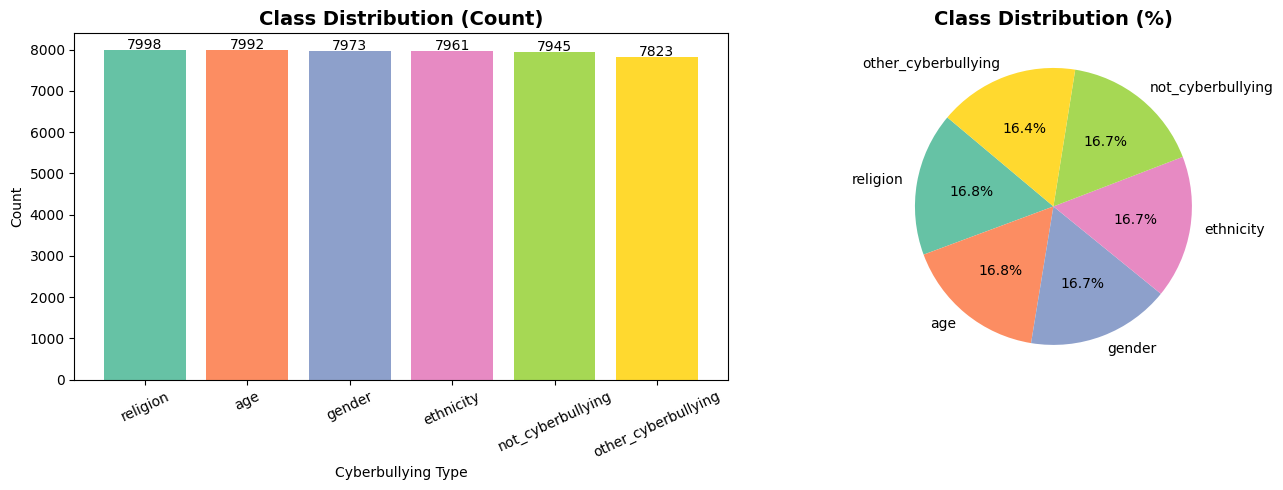


⚠️  Dataset is mildly imbalanced — will handle with class_weight + SMOTE


In [4]:
print("=" * 50)
print("Class Distribution")
print("=" * 50)
class_counts = df['cyberbullying_type'].value_counts()
print(class_counts)
print(f"\nImbalance ratio (max/min): {class_counts.max() / class_counts.min():.2f}x")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = sns.color_palette('Set2', len(class_counts))
axes[0].bar(class_counts.index, class_counts.values, color=colors)
axes[0].set_title('Class Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cyberbullying Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=25)
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=10)

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            startangle=140, colors=colors)
axes[1].set_title('Class Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n⚠️  Dataset is mildly imbalanced — will handle with class_weight + SMOTE")

Tweet Length Stats:
       tweet_length  word_count
count      47692.00    47692.00
mean         136.25       23.70
std           85.23       15.43
min            1.00        1.00
25%           78.00       13.00
50%          124.00       20.00
75%          180.00       32.00
max         5018.00      790.00


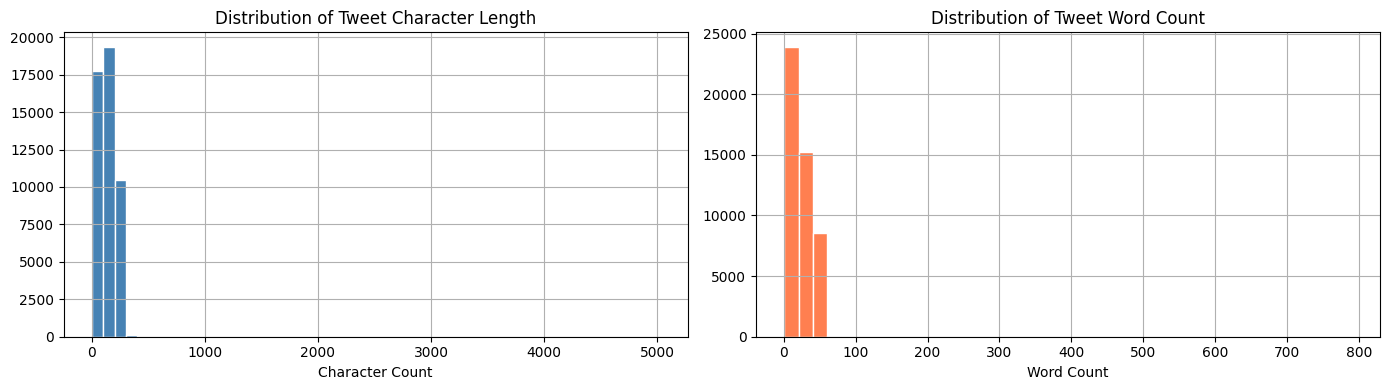

In [5]:
df['tweet_length'] = df['tweet_text'].astype(str).apply(len)
df['word_count']   = df['tweet_text'].astype(str).apply(lambda x: len(x.split()))

print("Tweet Length Stats:")
print(df[['tweet_length', 'word_count']].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['tweet_length'].hist(bins=50, color='steelblue', edgecolor='white', ax=axes[0])
axes[0].set_title('Distribution of Tweet Character Length')
axes[0].set_xlabel('Character Count')

df['word_count'].hist(bins=40, color='coral', edgecolor='white', ax=axes[1])
axes[1].set_title('Distribution of Tweet Word Count')
axes[1].set_xlabel('Word Count')

plt.tight_layout()
plt.savefig('text_length_dist.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🧹 3. Text Preprocessing

In [6]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Keep a small set of negation words — important for cyberbullying sentiment
negation_words = {'no', 'not', 'nor', 'never', 'neither', 'nobody', 'nothing', 'nowhere'}
stop_words -= negation_words

def preprocess_text(text):
    """Full preprocessing pipeline for tweets."""
    if not isinstance(text, str):
        return ""

    # 1. Lowercase
    text = text.lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # 3. Remove @mentions
    text = re.sub(r'@\w+', '', text)

    # 4. Remove hashtag symbol but keep the word
    text = re.sub(r'#(\w+)', r'\1', text)

    # 5. Remove HTML entities
    text = re.sub(r'&[a-z]+;', ' ', text)

    # 6. Remove numbers
    text = re.sub(r'\d+', '', text)

    # 7. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 8. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # 9. Tokenize, remove stopwords, lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 1]

    return ' '.join(tokens)

print("Preprocessing tweets...")
df['clean_text'] = df['tweet_text'].astype(str).apply(preprocess_text)
print(f"✅ Done! Processed {len(df)} tweets.")

# Show before/after
print("\n--- Before / After Sample ---")
for i in [0, 5, 10]:
    print(f"\n[{df['cyberbullying_type'].iloc[i]}]")
    print(f"  BEFORE: {df['tweet_text'].iloc[i][:120]}")
    print(f"  AFTER : {df['clean_text'].iloc[i][:120]}")

Preprocessing tweets...
✅ Done! Processed 47692 tweets.

--- Before / After Sample ---

[not_cyberbullying]
  BEFORE: In other words #katandandre, your food was crapilicious! #mkr
  AFTER : word katandandre food crapilicious mkr

[not_cyberbullying]
  BEFORE: @Raja5aab @Quickieleaks Yes, the test of god is that good or bad or indifferent or weird or whatever, it all proves gods
  AFTER : yes test god good bad indifferent weird whatever prof god existence

[not_cyberbullying]
  BEFORE: @Jord_Is_Dead http://t.co/UsQInYW5Gn
  AFTER : 


In [7]:
# Drop rows where clean_text became empty after preprocessing
before = len(df)
df = df[df['clean_text'].str.strip().str.len() > 0].reset_index(drop=True)
print(f"Removed {before - len(df)} empty rows after preprocessing. Remaining: {len(df)}")

Removed 322 empty rows after preprocessing. Remaining: 47370


---
## 🏷️ 4. Label Encoding & Train/Test Split

In [8]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['cyberbullying_type'])

print("Label Mapping:")
for cls, idx in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {idx} → {cls}")

X = df['clean_text']
y = df['label']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain size: {len(X_train_raw)}  |  Test size: {len(X_test_raw)}")
print("Train class distribution:")
print(pd.Series(y_train).map(dict(enumerate(le.classes_))).value_counts())

Label Mapping:
  0 → age
  1 → ethnicity
  2 → gender
  3 → not_cyberbullying
  4 → other_cyberbullying
  5 → religion

Train size: 37896  |  Test size: 9474
Train class distribution:
label
religion               6398
age                    6394
ethnicity              6367
gender                 6359
not_cyberbullying      6262
other_cyberbullying    6116
Name: count, dtype: int64


---
## 🔢 5. TF-IDF Vectorization

In [9]:
tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),       # unigrams + bigrams
    sublinear_tf=True,         # dampens frequency (log scaling)
    min_df=2,                  # ignore very rare terms
    max_df=0.95,               # ignore very common terms
    analyzer='word',
    strip_accents='unicode'
)

X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf  = tfidf.transform(X_test_raw)

print(f"TF-IDF Feature Matrix Shape:")
print(f"  Train: {X_train_tfidf.shape}")
print(f"  Test : {X_test_tfidf.shape}")

TF-IDF Feature Matrix Shape:
  Train: (37896, 30000)
  Test : (9474, 30000)


---
## ⚖️ 6. Handle Class Imbalance with SMOTE

In [10]:
print("Applying SMOTE to balance training classes...")
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_tfidf, y_train)

print(f"\nBefore SMOTE — Train shape: {X_train_tfidf.shape}")
print(f"After  SMOTE — Train shape: {X_train_sm.shape}")

print("\nClass distribution after SMOTE:")
unique, counts = np.unique(y_train_sm, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {le.classes_[u]}: {c}")

Applying SMOTE to balance training classes...

Before SMOTE — Train shape: (37896, 30000)
After  SMOTE — Train shape: (38388, 30000)

Class distribution after SMOTE:
  age: 6398
  ethnicity: 6398
  gender: 6398
  not_cyberbullying: 6398
  other_cyberbullying: 6398
  religion: 6398


---
## 🤖 7. Model Training & Evaluation

### Models:
1. **Logistic Regression** — strong baseline for text classification  
2. **Random Forest** — ensemble tree, handles non-linearity  
3. **Multinomial Naive Bayes** — classic text classification model  
4. **Gradient Boosting (sklearn)** — powerful boosting, no external dependency  

In [11]:
results = {}

def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    """Train, evaluate, and store results for a model."""
    print(f"\n{'='*60}")
    print(f"  Model: {name}")
    print(f"{'='*60}")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc     = accuracy_score(y_test, y_pred)
    f1_mac  = f1_score(y_test, y_pred, average='macro')
    f1_wt   = f1_score(y_test, y_pred, average='weighted')

    print(f"  Accuracy       : {acc:.4f} ({acc*100:.2f}%)")
    print(f"  F1 (macro)     : {f1_mac:.4f}")
    print(f"  F1 (weighted)  : {f1_wt:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    results[name] = {
        'model'   : model,
        'accuracy': acc,
        'f1_macro': f1_mac,
        'f1_weighted': f1_wt,
        'y_pred'  : y_pred
    }

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=30)
    ax.set_title(f'Confusion Matrix — {name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'cm_{name.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return model

### 7.1 Logistic Regression


  Model: Logistic Regression
  Accuracy       : 0.8168 (81.68%)
  F1 (macro)     : 0.8155
  F1 (weighted)  : 0.8179

  Classification Report:
                     precision    recall  f1-score   support

                age       0.95      0.97      0.96      1598
          ethnicity       0.98      0.98      0.98      1592
             gender       0.89      0.83      0.86      1590
  not_cyberbullying       0.55      0.54      0.54      1565
other_cyberbullying       0.58      0.63      0.60      1529
           religion       0.96      0.95      0.95      1600

           accuracy                           0.82      9474
          macro avg       0.82      0.81      0.82      9474
       weighted avg       0.82      0.82      0.82      9474



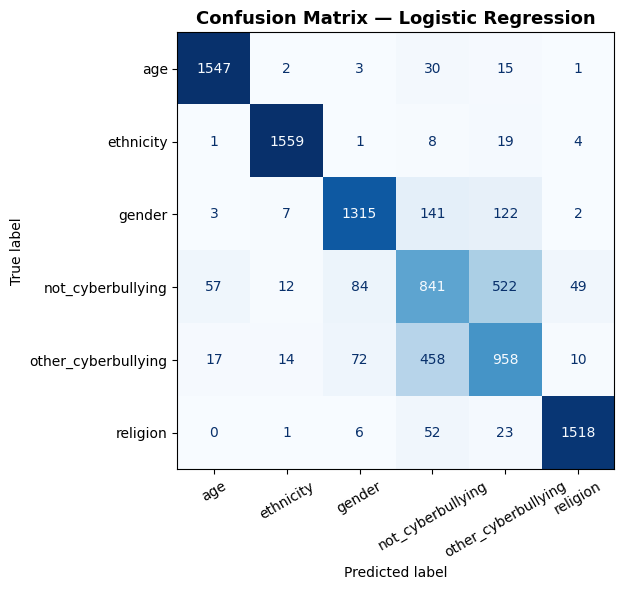

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",5.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [12]:
lr = LogisticRegression(
    C=5.0,
    max_iter=1000,
    solver='lbfgs',
   # multi_class='multinomial',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
evaluate_model('Logistic Regression', lr, X_train_sm, y_train_sm, X_test_tfidf, y_test)

### 7.3 Multinomial Naive Bayes


  Model: Multinomial NB
  Accuracy       : 0.7789 (77.89%)
  F1 (macro)     : 0.7683
  F1 (weighted)  : 0.7705

  Classification Report:
                     precision    recall  f1-score   support

                age       0.82      0.97      0.89      1598
          ethnicity       0.91      0.92      0.91      1592
             gender       0.86      0.78      0.82      1590
  not_cyberbullying       0.60      0.46      0.52      1565
other_cyberbullying       0.58      0.57      0.58      1529
           religion       0.84      0.95      0.89      1600

           accuracy                           0.78      9474
          macro avg       0.77      0.78      0.77      9474
       weighted avg       0.77      0.78      0.77      9474



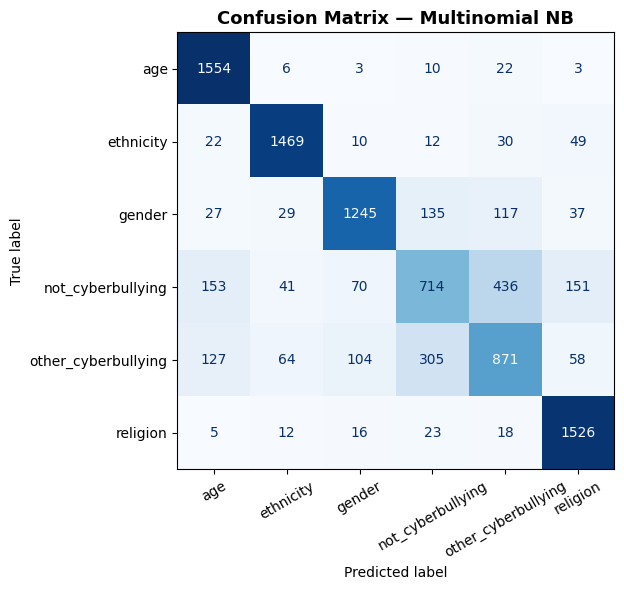

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",0.1
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [13]:
# Note: MultinomialNB requires non-negative features.
# SMOTE can produce negative values on sparse TF-IDF; clip to 0.
from scipy.sparse import csr_matrix
X_train_nb = csr_matrix(X_train_sm.copy())
X_train_nb.data = np.clip(X_train_nb.data, 0, None)

nb = MultinomialNB(alpha=0.1)
evaluate_model('Multinomial NB', nb, X_train_nb, y_train_sm, X_test_tfidf, y_test)

---
## 📊 8. Compare All Models


           MODEL COMPARISON SUMMARY
              Model  Accuracy  F1 (Macro)  F1 (Weighted)
Logistic Regression  0.816762    0.815450       0.817851
     Multinomial NB  0.778868    0.768307       0.770472


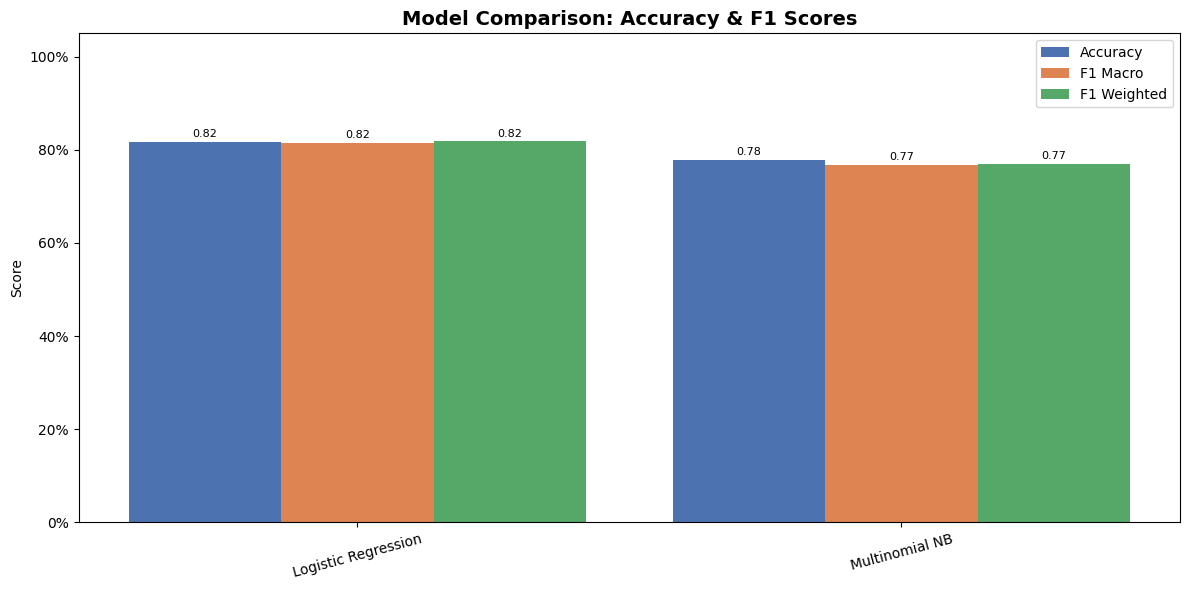

In [14]:
comparison_df = pd.DataFrame({
    'Model'       : list(results.keys()),
    'Accuracy'    : [results[m]['accuracy']    for m in results],
    'F1 (Macro)'  : [results[m]['f1_macro']    for m in results],
    'F1 (Weighted)': [results[m]['f1_weighted'] for m in results],
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("\n" + "="*65)
print("           MODEL COMPARISON SUMMARY")
print("="*65)
print(comparison_df.to_string(index=False))
print("="*65)

# Plot
x = np.arange(len(comparison_df))
width = 0.28
fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(x - width, comparison_df['Accuracy'],     width, label='Accuracy',     color='#4C72B0')
ax.bar(x,          comparison_df['F1 (Macro)'],  width, label='F1 Macro',     color='#DD8452')
ax.bar(x + width,  comparison_df['F1 (Weighted)'],width,label='F1 Weighted',  color='#55A868')

ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=15)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Comparison: Accuracy & F1 Scores', fontsize=14, fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=2, fontsize=8)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔍 9. Hyperparameter Tuning — Best Model (GridSearchCV)

In [15]:
best_name = comparison_df.iloc[0]['Model']
print(f"🏆 Best Model: {best_name}")
print(f"   Accuracy   : {comparison_df.iloc[0]['Accuracy']:.4f}")
print(f"   F1 (Macro) : {comparison_df.iloc[0]['F1 (Macro)']:.4f}")

🏆 Best Model: Logistic Regression
   Accuracy   : 0.8168
   F1 (Macro) : 0.8155


In [16]:
# GridSearchCV tuning for the best model
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

if best_name == 'Logistic Regression':
    param_grid = {
        'C'      : [1.0, 5.0, 10.0],
        'solver' : ['saga'],
        'max_iter': [10000]
    }
    base_model = LogisticRegression(
        class_weight='balanced', random_state=42, n_jobs=-1
    )

elif best_name == 'Random Forest':
    param_grid = {
        'n_estimators'    : [200, 300],
        'max_depth'       : [None, 50],
        'min_samples_leaf': [1, 2]
    }
    base_model = RandomForestClassifier(
        class_weight='balanced_subsample', random_state=42, n_jobs=-1
    )

elif best_name == 'Multinomial NB':
    param_grid = {'alpha': [0.05, 0.1, 0.5, 1.0]}
    base_model = MultinomialNB()

else:  # Hist Gradient Boosting
    param_grid = {
        'max_iter'       : [150, 200],
        'learning_rate'  : [0.05, 0.1],
        'max_leaf_nodes' : [31, 63]
    }
    base_model = HistGradientBoostingClassifier(
        class_weight='balanced', random_state=42
    )

print(f"\nRunning GridSearchCV for {best_name}...")
print(f"Parameter Grid: {param_grid}")

grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_sm, y_train_sm)

print(f"\n✅ Best Parameters: {grid_search.best_params_}")
print(f"   Best CV F1 (macro): {grid_search.best_score_:.4f}")


Running GridSearchCV for Logistic Regression...
Parameter Grid: {'C': [1.0, 5.0, 10.0], 'solver': ['saga'], 'max_iter': [10000]}
Fitting 5 folds for each of 3 candidates, totalling 15 fits

✅ Best Parameters: {'C': 1.0, 'max_iter': 10000, 'solver': 'saga'}
   Best CV F1 (macro): 0.8264


In [17]:
# Evaluate tuned model on test set
best_tuned = grid_search.best_estimator_
y_pred_tuned = best_tuned.predict(X_test_tfidf)

acc_tuned    = accuracy_score(y_test, y_pred_tuned)
f1_mac_tuned = f1_score(y_test, y_pred_tuned, average='macro')
f1_wt_tuned  = f1_score(y_test, y_pred_tuned, average='weighted')

print("\n" + "="*55)
print(f"  TUNED {best_name} — Test Set Results")
print("="*55)
print(f"  Accuracy       : {acc_tuned:.4f} ({acc_tuned*100:.2f}%)")
print(f"  F1 (Macro)     : {f1_mac_tuned:.4f}")
print(f"  F1 (Weighted)  : {f1_wt_tuned:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=le.classes_))

# Before vs After tuning
orig_acc = results[best_name]['accuracy']
print(f"  Accuracy before tuning: {orig_acc:.4f}")
print(f"  Accuracy after  tuning: {acc_tuned:.4f}  (Δ {(acc_tuned-orig_acc)*100:+.2f}%)")


  TUNED Logistic Regression — Test Set Results
  Accuracy       : 0.8282 (82.82%)
  F1 (Macro)     : 0.8273
  F1 (Weighted)  : 0.8295

Classification Report:
                     precision    recall  f1-score   support

                age       0.95      0.98      0.96      1598
          ethnicity       0.98      0.98      0.98      1592
             gender       0.91      0.82      0.86      1590
  not_cyberbullying       0.59      0.56      0.57      1565
other_cyberbullying       0.60      0.68      0.64      1529
           religion       0.96      0.94      0.95      1600

           accuracy                           0.83      9474
          macro avg       0.83      0.83      0.83      9474
       weighted avg       0.83      0.83      0.83      9474

  Accuracy before tuning: 0.8168
  Accuracy after  tuning: 0.8282  (Δ +1.14%)


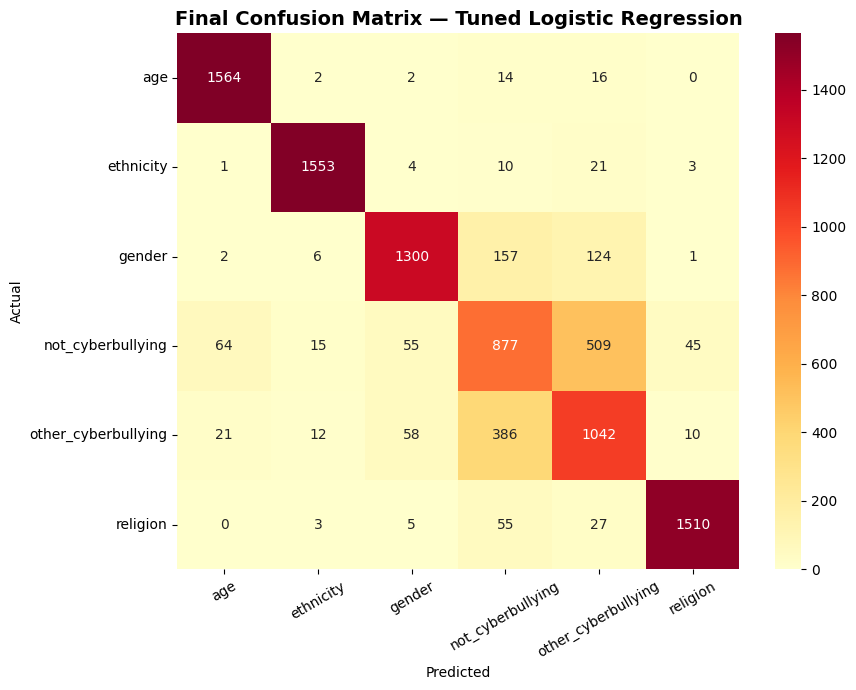

In [18]:
cm_final = confusion_matrix(y_test, y_pred_tuned)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title(f'Final Confusion Matrix — Tuned {best_name}', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('final_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 💾 10. Save Best Model & Artifacts

In [19]:
# Save TF-IDF vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# Save Label Encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# Save best tuned model
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_tuned, f)

# Save model metadata
metadata = {
    'best_model_name': best_name,
    'best_params': grid_search.best_params_,
    'accuracy': acc_tuned,
    'f1_macro': f1_mac_tuned,
    'f1_weighted': f1_wt_tuned,
    'classes': le.classes_.tolist()
}
import json
with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("✅ Saved:")
print("   • best_model.pkl")
print("   • tfidf_vectorizer.pkl")
print("   • label_encoder.pkl")
print("   • model_metadata.json")

✅ Saved:
   • best_model.pkl
   • tfidf_vectorizer.pkl
   • label_encoder.pkl
   • model_metadata.json


---
## 🧪 11. Quick Inference Test

In [20]:
def predict_cyberbullying(text):
    """Predict cyberbullying type for a given tweet."""
    cleaned = preprocess_text(text)
    vec = tfidf.transform([cleaned])
    pred = best_tuned.predict(vec)[0]
    label = le.inverse_transform([pred])[0]

    if hasattr(best_tuned, 'predict_proba'):
        proba = best_tuned.predict_proba(vec)[0]
        proba_dict = dict(zip(le.classes_, proba))
        sorted_proba = sorted(proba_dict.items(), key=lambda x: x[1], reverse=True)
        print(f"\nInput : {text[:80]}")
        print(f"Label : {label.upper()}")
        print("Probabilities:")
        for cls, prob in sorted_proba:
            bar = '█' * int(prob * 30)
            print(f"  {cls:<22} {bar:<30} {prob*100:.1f}%")
    else:
        print(f"Input : {text[:80]}")
        print(f"Label : {label.upper()}")

    return label

test_tweets = [
    "You are so ugly because of your skin color, go back to your country",
    "Happy birthday! Hope you have a great day!",
    "Old people should not be allowed to use the internet, they are useless",
    "Women should stay in the kitchen and not have opinions",
    "Your religion is stupid and your god is fake",
    "I don't think you're completely wrong, but the way you explained it was confusing and not very clear",
     "Go back to your country",
    "I really appreciate your help",
    "Old people are useless",
    "High school people are always wrong",
    "Nigga are always dumb",
    "you are sexist and idiot"
]

print("\n" + "="*65)
print("  INFERENCE EXAMPLES")
print("="*65)
for tweet in test_tweets:
    predict_cyberbullying(tweet)
    print("-"*65)


  INFERENCE EXAMPLES

Input : You are so ugly because of your skin color, go back to your country
Label : NOT_CYBERBULLYING
Probabilities:
  not_cyberbullying      ████████                       29.7%
  other_cyberbullying    ███████                        25.3%
  ethnicity              █████                          17.2%
  religion               ███                            11.2%
  gender                 ███                            10.6%
  age                    █                              6.1%
-----------------------------------------------------------------

Input : Happy birthday! Hope you have a great day!
Label : NOT_CYBERBULLYING
Probabilities:
  not_cyberbullying      ███████████████████            64.7%
  other_cyberbullying    █████                          19.4%
  ethnicity              █                              5.1%
  gender                 █                              4.3%
  religion               █                              4.2%
  age                  

---
## ✅ 12. Final Summary

In [21]:
print("\n" + "🔴" * 30)
print("          CYBERBULLYING NLP PROJECT — FINAL SUMMARY")
print("🔴" * 30)
print(f"\n📦 Dataset       : {len(df):,} tweets | 6 classes")
print(f"🔢 TF-IDF Feats  : {X_train_tfidf.shape[1]:,} features (unigram + bigram)")
print(f"⚖️  Imbalance     : Handled with SMOTE + class_weight")
print(f"\n📊 All Models Tested:")
for _, row in comparison_df.iterrows():
    marker = "🏆" if row['Model'] == best_name else "  "
    print(f"  {marker}  {row['Model']:<25}  Acc: {row['Accuracy']*100:.2f}%  F1: {row['F1 (Macro)']:.4f}")
print(f"\n🏆 Best Model      : {best_name}")
print(f"   Best Params     : {grid_search.best_params_}")
print(f"   Final Accuracy  : {acc_tuned*100:.2f}%")
print(f"   F1 (Macro)      : {f1_mac_tuned:.4f}")
print(f"   F1 (Weighted)   : {f1_wt_tuned:.4f}")
print(f"\n💾 Saved Artifacts  : best_model.pkl, tfidf_vectorizer.pkl, label_encoder.pkl")
print("\n✅ Ready for Streamlit deployment!")


🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴
          CYBERBULLYING NLP PROJECT — FINAL SUMMARY
🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴

📦 Dataset       : 47,370 tweets | 6 classes
🔢 TF-IDF Feats  : 30,000 features (unigram + bigram)
⚖️  Imbalance     : Handled with SMOTE + class_weight

📊 All Models Tested:
  🏆  Logistic Regression        Acc: 81.68%  F1: 0.8155
      Multinomial NB             Acc: 77.89%  F1: 0.7683

🏆 Best Model      : Logistic Regression
   Best Params     : {'C': 1.0, 'max_iter': 10000, 'solver': 'saga'}
   Final Accuracy  : 82.82%
   F1 (Macro)      : 0.8273
   F1 (Weighted)   : 0.8295

💾 Saved Artifacts  : best_model.pkl, tfidf_vectorizer.pkl, label_encoder.pkl

✅ Ready for Streamlit deployment!


---
## 🚀 13. Streamlit App — `app.py`

Run the cell below to generate the Streamlit app file, then launch it with:
```bash
streamlit run app.py
```